<a href="https://colab.research.google.com/github/shumailkhan845/CV-lab-4/blob/main/CV-lab-04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub opencv-python-headless

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from pathlib import Path

In [3]:
dataset_path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

print("Dataset path:")
print(dataset_path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset path:
/kaggle/input/skin-cancer-mnist-ham10000


In [4]:
metadata_path = None

for root, dirs, files in os.walk(dataset_path):
    if "HAM10000_metadata.csv" in files:
        metadata_path = os.path.join(root, "HAM10000_metadata.csv")
        break

print("Metadata path:")
print(metadata_path)

Metadata path:
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


In [5]:
df = pd.read_csv(metadata_path)

print("Number of images:", len(df))
print("\nColumns:")
print(df.columns.tolist())

df.head()

Number of images: 10015

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [6]:
image_paths = {}

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_id = os.path.splitext(file)[0]
            image_paths[image_id] = os.path.join(root, file)

print("Number of image files found:", len(image_paths))

Number of image files found: 10015


In [7]:
df["image_path"] = df["image_id"].map(image_paths)

print("Images with valid paths:",
      df["image_path"].notna().sum())

df[["image_id", "dx", "image_path"]].head()

Images with valid paths: 10015


,image_id,dx,image_path
0,ISIC_0027419,bkl,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
1,ISIC_0025030,bkl,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
2,ISIC_0026769,bkl,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
3,ISIC_0025661,bkl,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
4,ISIC_0031633,bkl,/kaggle/input/skin-cancer-mnist-ham10000/ham10...


In [8]:
selected_classes = ["akiec", "bcc", "bkl", "mel", "nv"]

selected_images = []

for lesion_class in selected_classes:
    sample = df[df["dx"] == lesion_class].iloc[0]
    selected_images.append(sample)

selected_df = pd.DataFrame(selected_images)

selected_df[
    ["image_id", "dx", "age", "sex", "localization", "image_path"]
]

,image_id,dx,age,sex,localization,image_path
9687,ISIC_0029417,akiec,80.0,female,neck,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
2462,ISIC_0028155,bcc,50.0,male,back,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
0,ISIC_0027419,bkl,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
1211,ISIC_0025964,mel,40.0,female,chest,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
64,ISIC_0024698,nv,70.0,male,face,/kaggle/input/skin-cancer-mnist-ham10000/ham10...


In [9]:
images = []

for _, row in selected_df.iterrows():
    image = cv2.imread(row["image_path"])

    if image is None:
        print("Could not load:", row["image_path"])
        continue

    # Convert BGR → RGB for matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    images.append({
        "image_id": row["image_id"],
        "label": row["dx"],
        "image": image_rgb
    })

print("Images successfully loaded:", len(images))

Images successfully loaded: 5


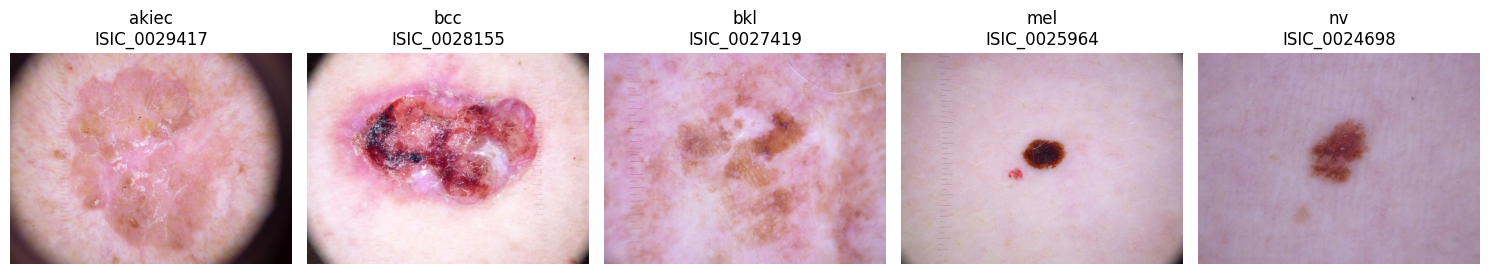

In [10]:
plt.figure(figsize=(15, 8))

for i, item in enumerate(images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(item["image"])
    plt.title(f"{item['label']}\n{item['image_id']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**TASK 2**

In [11]:
processed_images = []

for item in images:

    rgb = item["image"]

    # RGB → grayscale
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

    # Gaussian filtering
    gaussian = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    processed_images.append({
        "image_id": item["image_id"],
        "label": item["label"],
        "original": rgb,
        "gray": gray,
        "gaussian": gaussian
    })

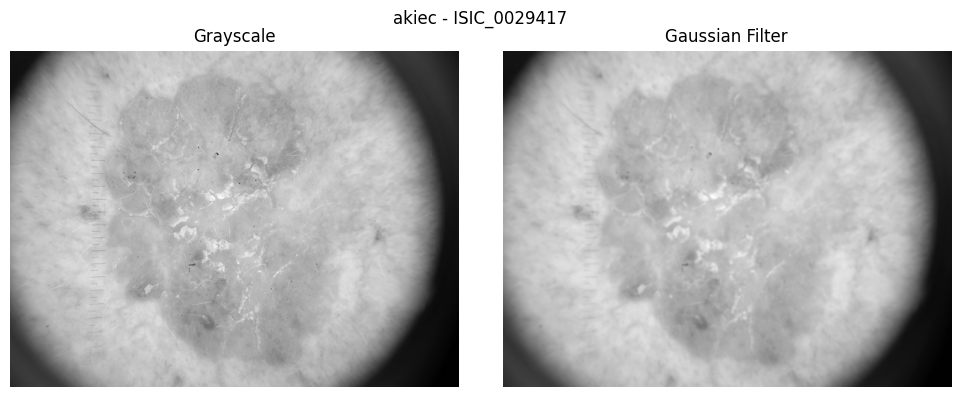

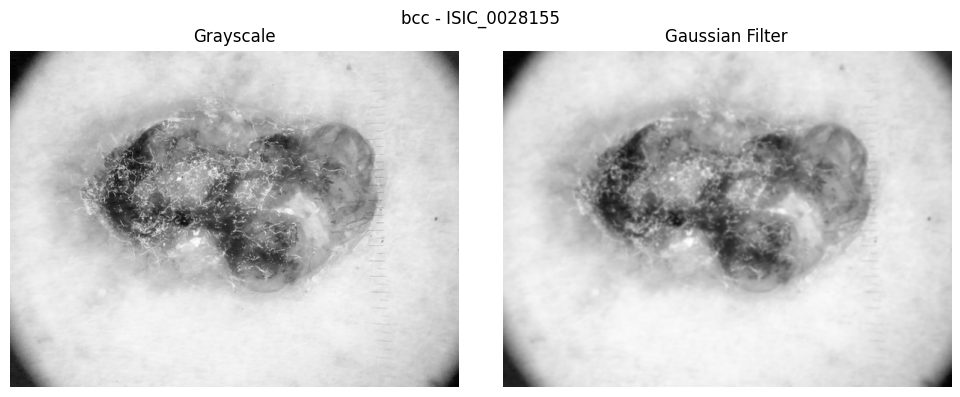

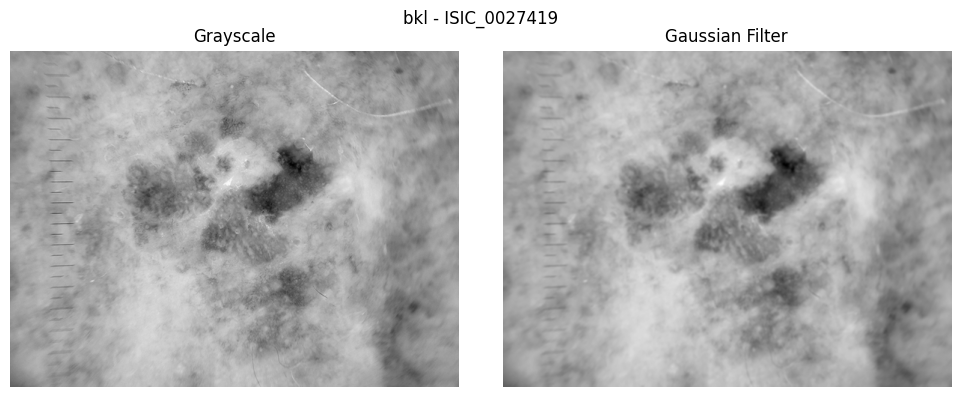

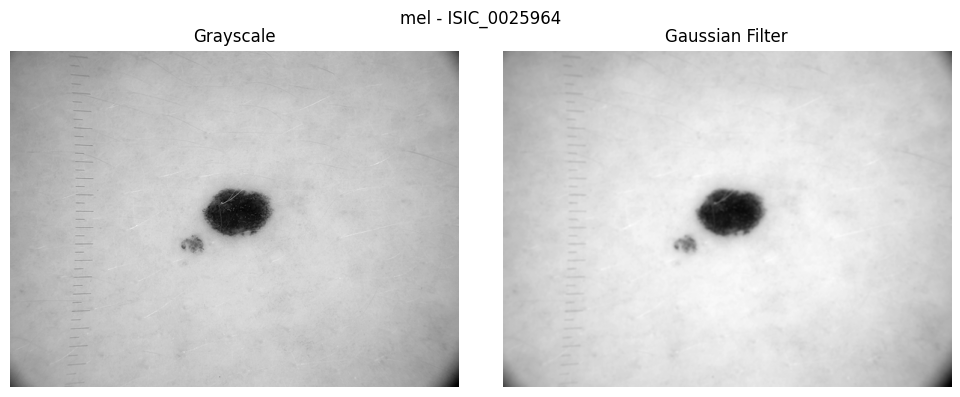

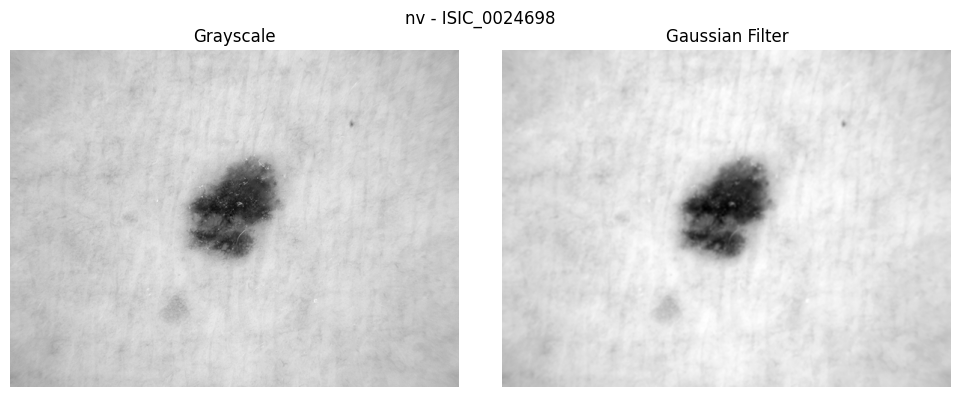

In [12]:
for item in processed_images:

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(item["gray"], cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(item["gaussian"], cmap="gray")
    plt.title("Gaussian Filter")
    plt.axis("off")

    plt.suptitle(
        f"{item['label']} - {item['image_id']}"
    )

    plt.tight_layout()
    plt.show()

**Task 3**

In [13]:
canny_results = {}

thresholds = [
    (50, 100),
    (100, 200),
    (150, 250)
]

for item in processed_images:

    image_id = item["image_id"]
    gaussian = item["gaussian"]

    canny_results[image_id] = {}

    for low, high in thresholds:

        edges = cv2.Canny(
            gaussian,
            low,
            high
        )

        canny_results[image_id][(low, high)] = edges

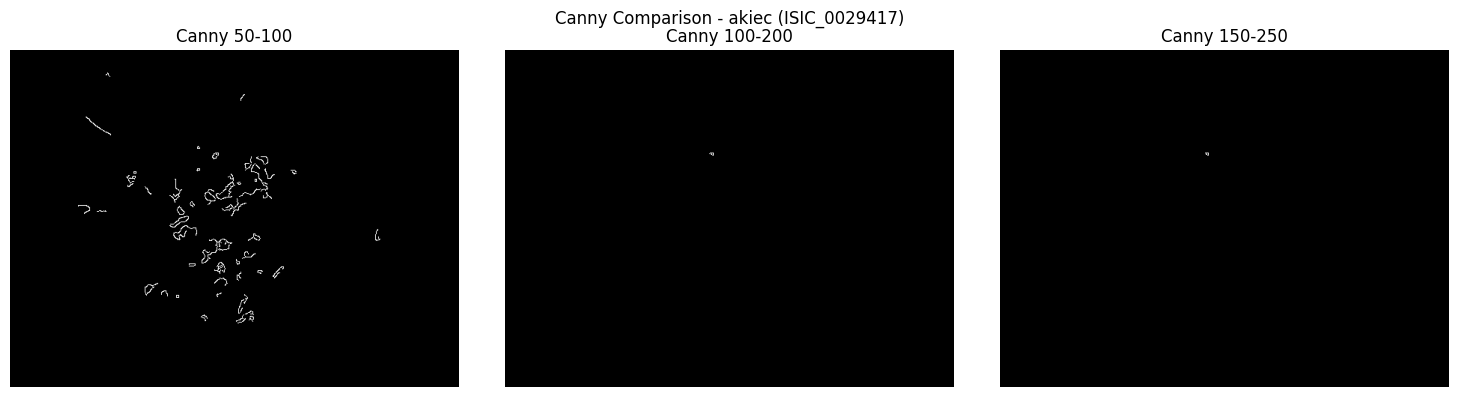

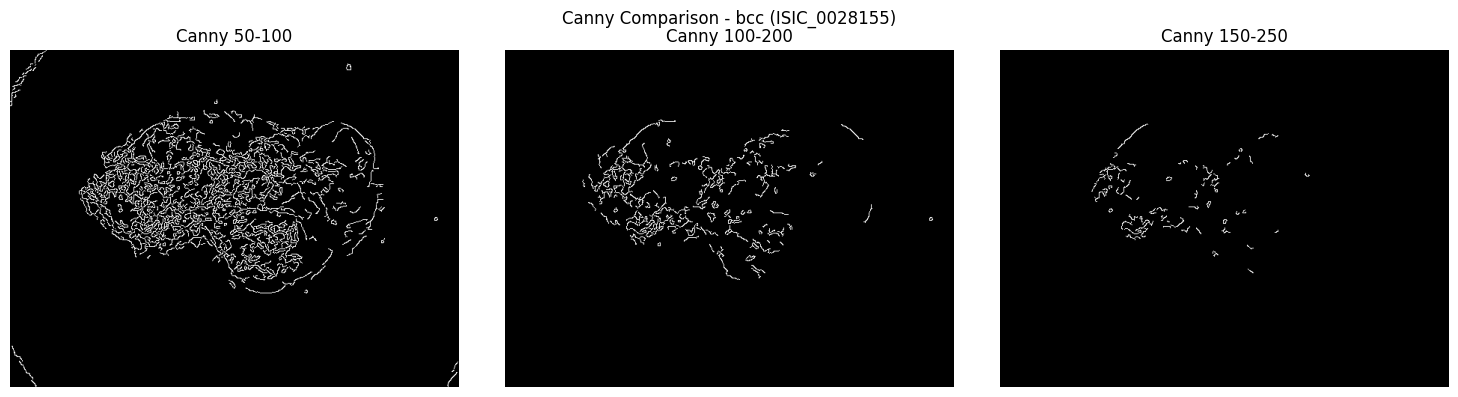

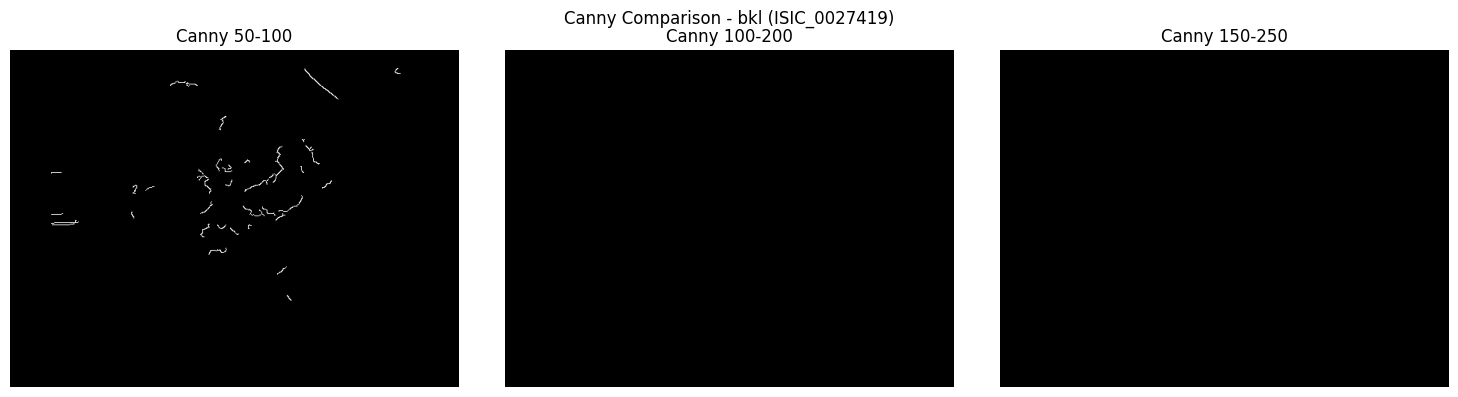

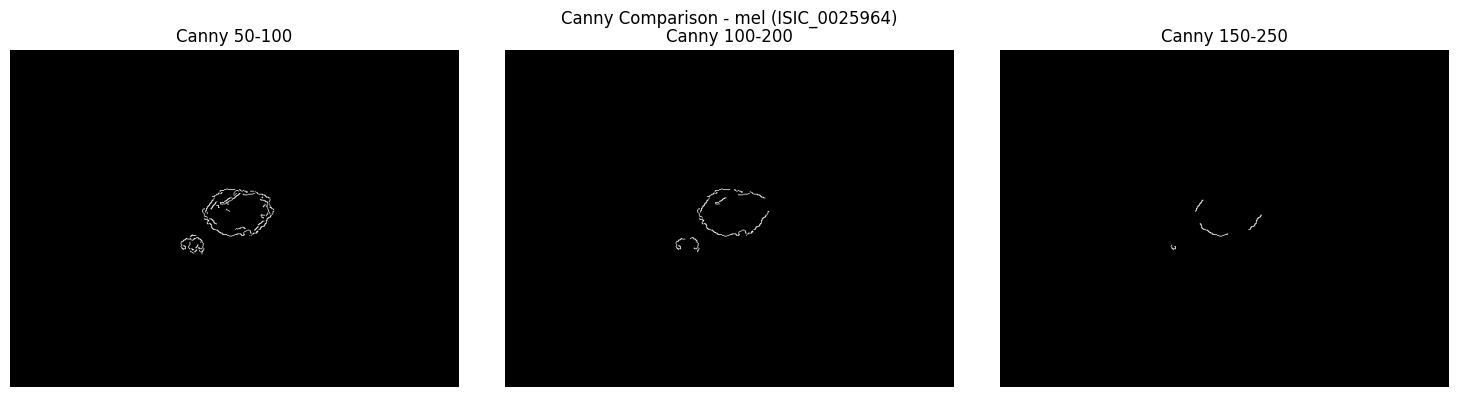

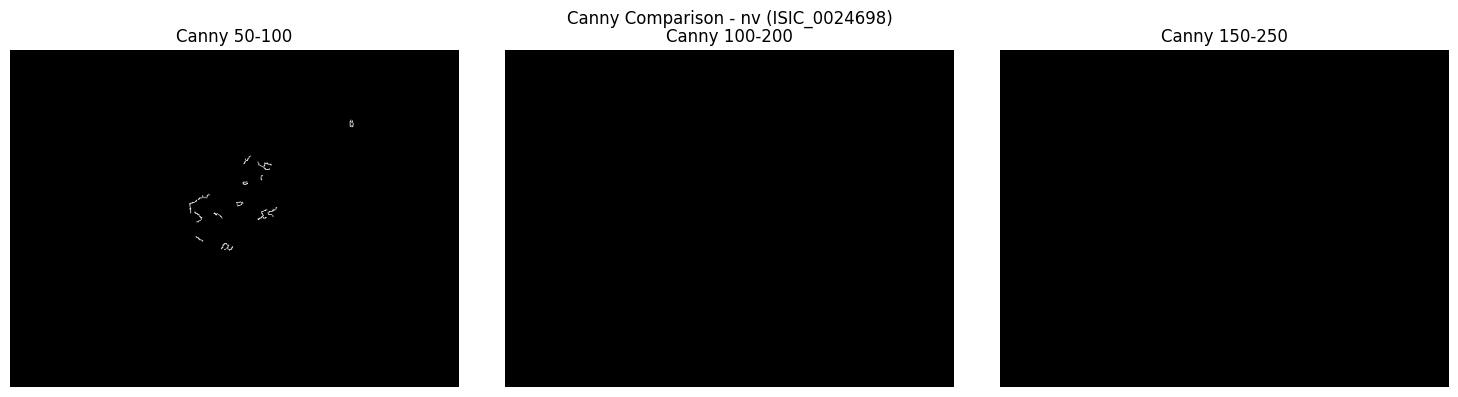

In [14]:
for item in processed_images:

    image_id = item["image_id"]

    plt.figure(figsize=(15, 4))

    for i, (low, high) in enumerate(thresholds):

        edges = canny_results[image_id][(low, high)]

        plt.subplot(1, 3, i + 1)
        plt.imshow(edges, cmap="gray")
        plt.title(f"Canny {low}-{high}")
        plt.axis("off")

    plt.suptitle(
        f"Canny Comparison - {item['label']} ({image_id})"
    )

    plt.tight_layout()
    plt.show()

**TASK 4**

In [15]:
best_thresholds = {
    # Replace these after looking at the Canny results
    processed_images[0]["image_id"]: (100, 200),
    processed_images[1]["image_id"]: (100, 200),
    processed_images[2]["image_id"]: (100, 200),
    processed_images[3]["image_id"]: (100, 200),
    processed_images[4]["image_id"]: (100, 200)
}

print(best_thresholds)

{'ISIC_0029417': (100, 200), 'ISIC_0028155': (100, 200), 'ISIC_0027419': (100, 200), 'ISIC_0025964': (100, 200), 'ISIC_0024698': (100, 200)}


**TASK 5**

In [32]:
boundary_results = {}

for item in processed_images:

    image_id = item["image_id"]

    low, high = best_thresholds[image_id]

    # Gaussian image
    gaussian = item["gaussian"]

    # Canny edges
    edges = cv2.Canny(
        gaussian,
        low,
        high
    )

    # -----------------------------------
    # Step 1: Morphological processing
    # -----------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (15, 15)
    )

    closed = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=3
    )

    # -----------------------------------
    # Step 2: Dilate edges
    # -----------------------------------

    dilated = cv2.dilate(
        closed,
        kernel,
        iterations=1
    )

    # -----------------------------------
    # Step 3: Find contours
    # -----------------------------------

    contours, _ = cv2.findContours(
        dilated,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # -----------------------------------
    # Step 4: If Canny gives contours
    # -----------------------------------

    if len(contours) > 0:

        # Remove extremely tiny contours
        contours = [
            c for c in contours
            if cv2.contourArea(c) > 100
        ]

    # -----------------------------------
    # Step 5: If no contour exists,
    # use thresholding
    # -----------------------------------

    if len(contours) == 0:

        print(
            "Canny contour unavailable, "
            "using thresholding:",
            image_id
        )

        # Otsu thresholding
        _, binary = cv2.threshold(
            gaussian,
            0,
            255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )

        # Clean binary image
        binary = cv2.morphologyEx(
            binary,
            cv2.MORPH_CLOSE,
            kernel,
            iterations=2
        )

        binary = cv2.morphologyEx(
            binary,
            cv2.MORPH_OPEN,
            cv2.getStructuringElement(
                cv2.MORPH_ELLIPSE,
                (5, 5)
            )
        )

        contours, _ = cv2.findContours(
            binary,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if len(contours) == 0:
            print("Still no contour:", image_id)
            continue

    # -----------------------------------
    # Step 6: Select largest contour
    # -----------------------------------

    best_contour = max(
        contours,
        key=cv2.contourArea
    )

    boundary_results[image_id] = {
        "edges": edges,
        "closed": closed,
        "contour": best_contour
    }


print("\nImages with detected boundaries:",
      len(boundary_results))

print(boundary_results.keys())

Canny contour unavailable, using thresholding: ISIC_0027419
Canny contour unavailable, using thresholding: ISIC_0024698

Images with detected boundaries: 5
dict_keys(['ISIC_0027419', 'ISIC_0024698', 'ISIC_0025964', 'ISIC_0028155', 'ISIC_0029417'])


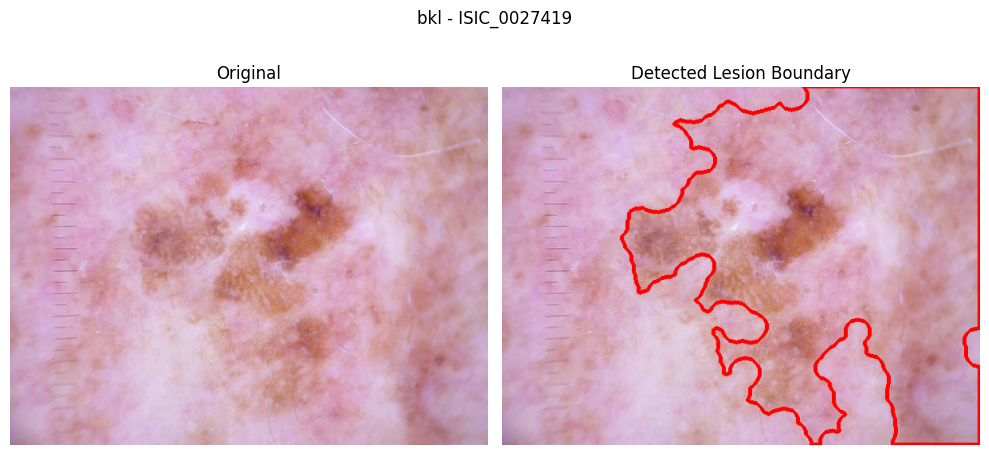

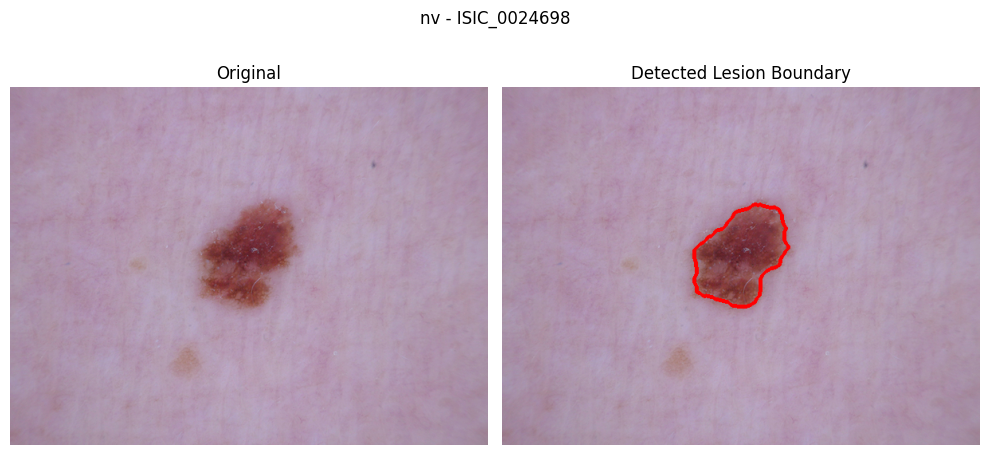

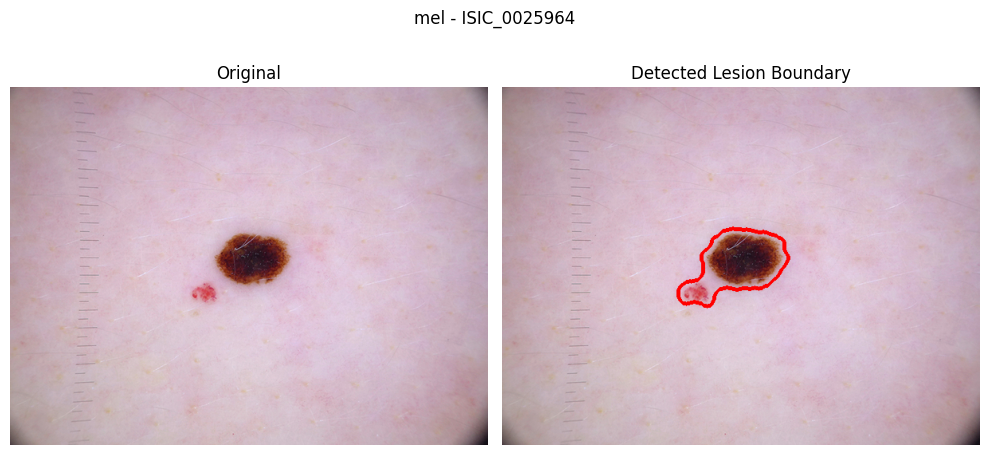

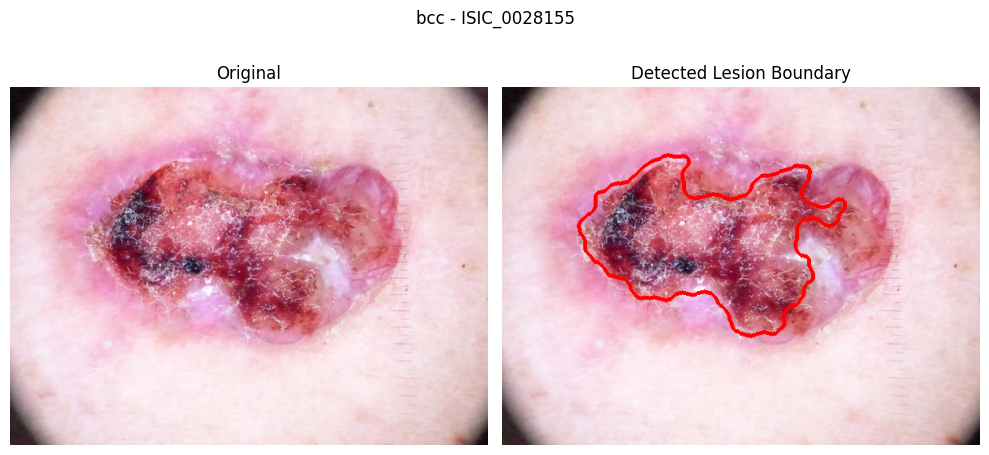

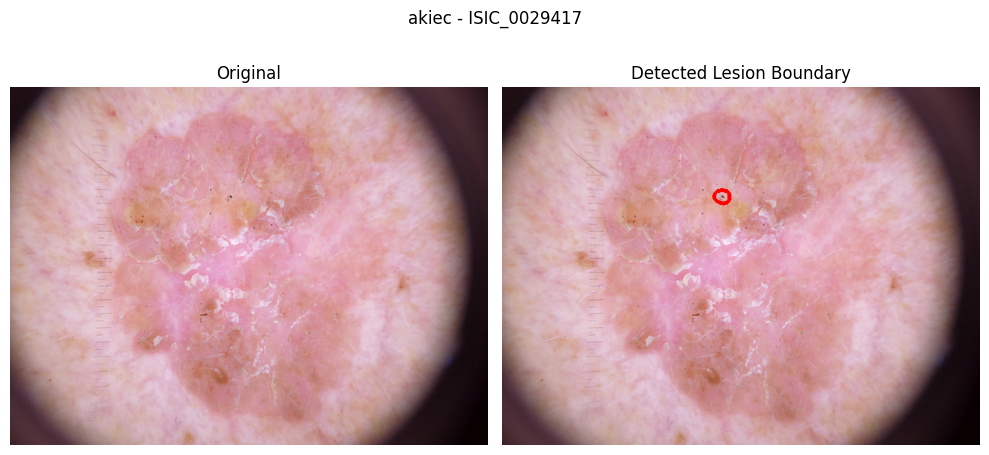

In [33]:
for item in processed_images:

    image_id = item["image_id"]

    if image_id not in boundary_results:
        continue

    contour = boundary_results[image_id]["contour"]

    result = item["original"].copy()

    cv2.drawContours(
        result,
        [contour],
        -1,
        (255, 0, 0),
        3
    )

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(item["original"])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title("Detected Lesion Boundary")
    plt.axis("off")

    plt.suptitle(
        f"{item['label']} - {image_id}"
    )

    plt.tight_layout()
    plt.show()

**TASK 6**

In [34]:
results = []

for item in processed_images:

    image_id = item["image_id"]

    if image_id not in boundary_results:
        continue

    contour = boundary_results[image_id]["contour"]

    area = cv2.contourArea(contour)

    perimeter = cv2.arcLength(
        contour,
        True
    )

    low, high = best_thresholds[image_id]

    results.append({
        "Image": image_id,
        "Class": item["label"],
        "Best Filter": "Gaussian",
        "Edge Method": f"Canny {low}-{high}",
        "Area (pixels)": round(area, 2),
        "Perimeter (pixels)": round(perimeter, 2)
    })

results_df = pd.DataFrame(results)

results_df

,Image,Class,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,ISIC_0027419,bkl,Gaussian,Canny 100-200,137194.5,2511.54
1,ISIC_0024698,nv,Gaussian,Canny 100-200,10198.5,424.23
2,ISIC_0025964,mel,Gaussian,Canny 100-200,7830.0,416.82
3,ISIC_0028155,bcc,Gaussian,Canny 100-200,42434.0,1151.97
4,ISIC_0029417,akiec,Gaussian,Canny 100-200,255.5,60.87


| Method               | Noise Handling | Edge Quality  | Boundary Detection | Overall Performance |
| -------------------- | -------------- | ------------- | ------------------ | ------------------- |
| Original + Sobel     | Poor           | Moderate      | Moderate           | Moderate            |
| Original + Canny     | Poor           | Good          | Good               | Good                |
| Average + Sobel      | Moderate       | Moderate      | Moderate           | Moderate            |
| Average + Canny      | Moderate       | Good          | Good               | Good                |
| Gaussian + Sobel     | Good           | Good          | Good               | Good                |
| **Gaussian + Canny** | **Very Good**  | **Very Good** | **Very Good**      | **Very Good**       |
| Median + Sobel       | Very Good      | Good          | Good               | Good                |
| Median + Canny       | Very Good      | Very Good     | Very Good          | Very Good           |
